# 03_exploratory_analysis.ipynb
Explore the cleaned and generated datasets through descriptive statistics, correlations, distributions, groupby analysis, and trend analysis.

In [7]:
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from faker import Faker
warnings.filterwarnings('ignore')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DATA_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DATA_DIR = BASE_DIR / 'data' / 'processed'
GENERATED_DATA_DIR = BASE_DIR / 'data' / 'generated'
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_DATA_DIR.mkdir(parents=True, exist_ok=True)
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
import src.generate_data as generate_data
print('Setup complete')

Setup complete


## Setup and Import Libraries  
Initialize all required libraries and configure data paths. This prepares the environment for data loading and analysis.

In [8]:
# Ensure and load datasets
if not sorted(GENERATED_DATA_DIR.glob('*.csv')):
    generate_data.generate_all(n_each=1000, out_dir=GENERATED_DATA_DIR)
sales = pd.read_csv(GENERATED_DATA_DIR / 'sales_orders.csv')
barangay = pd.read_csv(GENERATED_DATA_DIR / 'barangay_census.csv')
medical = pd.read_csv(GENERATED_DATA_DIR / 'medical_records.csv')
enrollment = pd.read_csv(GENERATED_DATA_DIR / 'school_enrollment.csv')
for frame, date_col in [(sales, 'order_date'), (medical, 'visit_date'), (enrollment, 'birth_date')]:
    if date_col in frame.columns:
        frame[date_col] = pd.to_datetime(frame[date_col], errors='coerce')
print('Loaded shapes:', sales.shape, barangay.shape, medical.shape, enrollment.shape)

Loaded shapes: (1020, 10) (1020, 7) (1020, 10) (1020, 10)


## Load and Prepare Datasets
Load all four datasets from the generated data directory. Convert date columns to datetime format for proper time-based analysis. This creates the foundation for all subsequent analysis.

In [9]:
# Descriptive statistics
display(sales.describe(include='all').transpose())
display(barangay.describe(include='all').transpose())

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,1020,1000,SO-100778,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,1020,NaN,NaN,NaN,2026-05-24 00:00:00,2026-05-24 00:00:00,2026-05-24 00:00:00,2026-05-24 00:00:00,2026-05-24 00:00:00,2026-05-24 00:00:00,NaN
customer_name,1020,994,William Macdonald,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
barangay,1020,12,Rizal,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,1020,8,Instant Noodles,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1020,4,Beverage,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,970.0,NaN,NaN,NaN,4.210309,1.0,2.0,4.0,5.0,32.0,3.44215
unit_price,970.0,NaN,NaN,NaN,539.985165,37.92,283.3625,513.985,736.3775,4052.72,442.229721
total_amount,970.0,NaN,NaN,NaN,2105.667052,38.43,749.94,1683.905,2849.415,13335.92,1894.129979
payment_method,1020,4,GCash,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1020.0,NaN,NaN,NaN,500.081373,288.836576,1.0,249.75,498.5,751.25,1000.0
barangay,1020,12,Poblacion,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1020,6,Quezon City,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
households,970.0,NaN,NaN,NaN,214.862887,142.422752,160.0,191.0,201.0,209.0,1604.0
population,970.0,NaN,NaN,NaN,861.862887,599.50669,480.0,630.0,816.0,960.0,6496.0
median_income,970.0,NaN,NaN,NaN,19421.549485,14191.698622,8000.0,13056.75,17881.0,22971.0,142372.0
collection_date,1020,558,2025-04-10,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Descriptive Statistics
Generate summary statistics (mean, median, count, etc.) for each dataset. This reveals central tendencies, ranges, and data types at a glance.

In [10]:
# Groupby analysis
barangay_revenue = sales.groupby('barangay', dropna=False)['total_amount'].sum().sort_values(ascending=False).head(10)
display(barangay_revenue.to_frame('revenue'))
diagnosis_counts = medical['diagnosis'].value_counts().head(10)
display(diagnosis_counts.to_frame('count'))

,revenue
barangay,
Rizal,196685.77
Poblacion,190328.51
Bagong Silang,183583.38
Bayanihan,178071.45
San Jose,177764.51
Sta. Cruz,176422.39
Del Pilar,170964.99
Magsaysay,162899.63
Maligaya,162160.01


,count
diagnosis,
Diabetes,181
Asthma,180
Checkup,174
Infection,170
Fever,167
Hypertension,148


## Groupby Analysis
Aggregate data by categories (e.g., revenue by barangay, diagnosis frequency). This reveals which categories drive performance and identify key patterns in the data.

In [11]:
# Trend analysis
monthly_sales = sales.dropna(subset=['order_date']).set_index('order_date').resample('M')['total_amount'].sum().reset_index()
fig = px.line(monthly_sales, x='order_date', y='total_amount', title='Monthly Sales Trend')
fig.show()

## Time Series Trends
Resample sales data by month to reveal temporal patterns and seasonality. This helps forecast demand and identify peak/low periods.

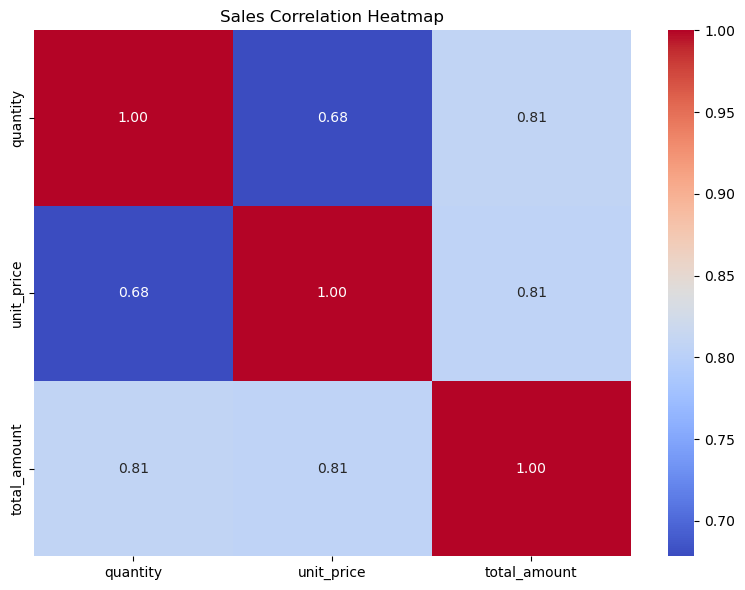

In [12]:
# Correlations
numeric_sales = sales.select_dtypes(include=['number']).copy()
corr = numeric_sales.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sales Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Analysis
Calculate and visualize correlations between numeric variables. A heatmap shows which variables move together, revealing relationships and dependencies in the data.

## Business insights
The sales and health datasets show category and diagnosis patterns that can be used for dashboard storytelling and stakeholder reporting.